In [ ]:
!pip install xgboost opencv-python kagglehub -q

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [ ]:
#path
path = kagglehub.dataset_download(
    "sartajbhuvaji/brain-tumor-classification-mri"
)

print("Dataset Path:", path)

100%|██████████| 86.8M/86.8M [00:00<00:00, 117MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/3


In [ ]:
#define classes
classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

In [ ]:
#load dataset
IMG_SIZE = 200

def load_images(folder_path):

    X = []
    Y = []

    for cls, label in classes.items():

        class_path = os.path.join(folder_path, cls)

        for filename in os.listdir(class_path):

            img_path = os.path.join(class_path, filename)

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is not None:

                img = cv2.resize(
                    img,
                    (IMG_SIZE, IMG_SIZE)
                )

                img = img.flatten() / 255.0

                X.append(img)

                Y.append(label)

    return np.array(X, dtype=np.float32), np.array(Y)


# LOAD TRAINING DATA
train_path = os.path.join(path, "Training")

X_train, Y_train = load_images(train_path)

# LOAD TESTING DATA
test_path = os.path.join(path, "Testing")

X_test, Y_test = load_images(test_path)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (2870, 40000)
Testing Shape  : (394, 40000)


In [ ]:
#train percentages
train_sizes = [0.2, 0.4, 0.6, 0.8]


TRAINING DATA USED : 20%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 574
Testing Samples  : 394
PCA Components Retained : 327

Training XGBoost Model...
Training Completed
Training Accuracy : 0.9564459930313589
Testing Accuracy  : 0.46446700507614214
F1 Score          : 0.44922113594439866

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.53      0.47      0.49       105
 Pituitary Tumor       0.43      0.58      0.49        74
    Glioma Tumor       0.36      0.20      0.26       100
Meningioma Tumor       0.49      0.62      0.55       115

        accuracy                           0.46       394
       macro avg       0.45      0.47      0.45       394
    weighted avg       0.45      0.46      0.45       394



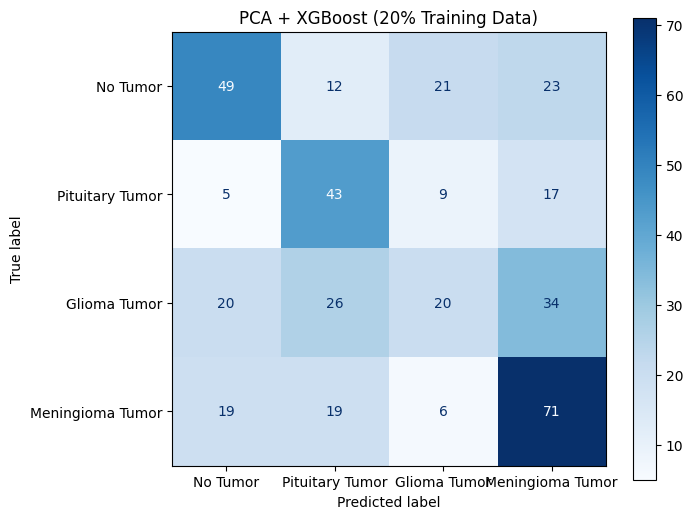


TRAINING DATA USED : 40%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 1148
Testing Samples  : 394
PCA Components Retained : 546

Training XGBoost Model...
Training Completed
Training Accuracy : 0.8989547038327527
Testing Accuracy  : 0.5253807106598984
F1 Score          : 0.4994850089491069

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.58      0.53      0.56       105
 Pituitary Tumor       0.50      0.76      0.60        74
    Glioma Tumor       0.43      0.18      0.25       100
Meningioma Tumor       0.53      0.67      0.59       115

        accuracy                           0.53       394
       macro avg       0.51      0.53      0.50       394
    weighted avg       0.51      0.53      0.50       394



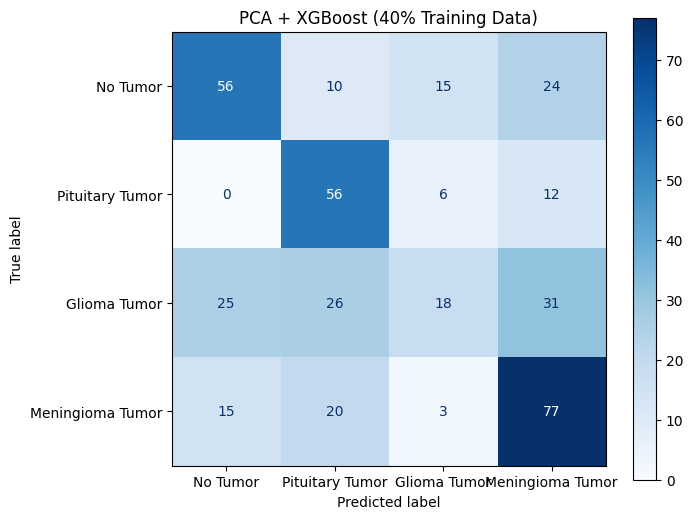


TRAINING DATA USED : 60%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 1722
Testing Samples  : 394
PCA Components Retained : 694

Training XGBoost Model...
Training Completed
Training Accuracy : 0.8658536585365854
Testing Accuracy  : 0.5456852791878173
F1 Score          : 0.5251155244393906

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.72      0.58      0.64       105
 Pituitary Tumor       0.51      0.65      0.57        74
    Glioma Tumor       0.35      0.19      0.25       100
Meningioma Tumor       0.54      0.76      0.63       115

        accuracy                           0.55       394
       macro avg       0.53      0.54      0.52       394
    weighted avg       0.53      0.55      0.53       394



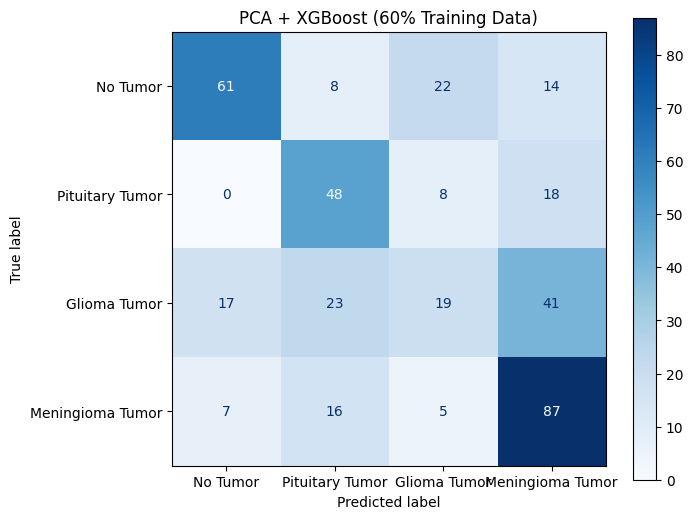


TRAINING DATA USED : 80%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 2296
Testing Samples  : 394
PCA Components Retained : 804

Training XGBoost Model...
Training Completed
Training Accuracy : 0.8327526132404182
Testing Accuracy  : 0.5558375634517766
F1 Score          : 0.5337351617565135

Classification Report:

                  precision    recall  f1-score   support

        No Tumor       0.65      0.58      0.61       105
 Pituitary Tumor       0.55      0.65      0.59        74
    Glioma Tumor       0.40      0.21      0.28       100
Meningioma Tumor       0.56      0.77      0.65       115

        accuracy                           0.56       394
       macro avg       0.54      0.55      0.53       394
    weighted avg       0.54      0.56      0.53       394



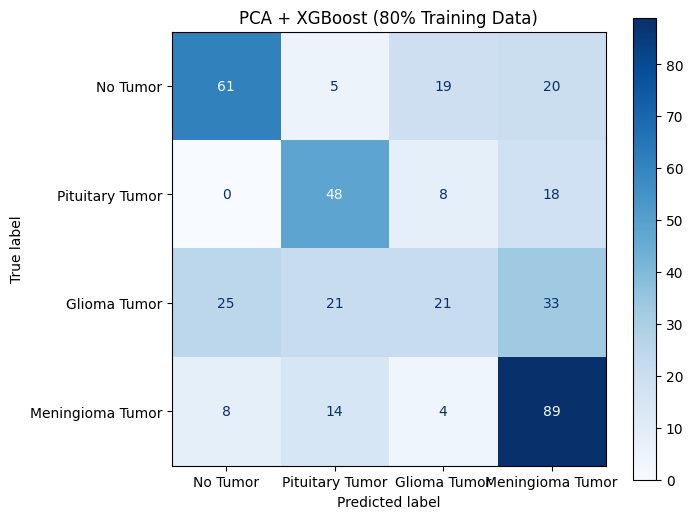

In [ ]:
#pca+xgboost training

train_acc_list = []

test_acc_list = []

f1_list = []

labels = []

for train_size in train_sizes:

    print("\n====================================")
    print(f"TRAINING DATA USED : {int(train_size*100)}%")
    print("TESTING DATA USED  : 100% Official Test Set")
    print("====================================")

    # TAKE SUBSET OF TRAINING DATA
    xtrain, _, ytrain, _ = train_test_split(
        X_train,
        Y_train,
        train_size=train_size,
        random_state=42,
        stratify=Y_train
    )

    print("Training Samples :", xtrain.shape[0])

    print("Testing Samples  :", X_test.shape[0])

    # PCA
    pca = PCA(
        n_components=0.95,
        random_state=42
    )

    pca_train = pca.fit_transform(xtrain)

    pca_test = pca.transform(X_test)

    print("PCA Components Retained :", pca.n_components_)

    # XGBOOST MODEL
    xgb = XGBClassifier(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    print("\nTraining XGBoost Model...")

    xgb.fit(
        pca_train,
        ytrain
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb.predict(pca_train)

    test_pred = xgb.predict(pca_test)

    # METRICS
    train_acc = accuracy_score(
        ytrain,
        train_pred
    )

    test_acc = accuracy_score(
        Y_test,
        test_pred
    )

    f1 = f1_score(
        Y_test,
        test_pred,
        average='weighted'
    )

    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)
    print("F1 Score          :", f1)

    train_acc_list.append(train_acc)

    test_acc_list.append(test_acc)

    f1_list.append(f1)

    labels.append(
        f"{int(train_size*100)}%"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            Y_test,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    cm = confusion_matrix(
        Y_test,
        test_pred
    )

    fig, ax = plt.subplots(figsize=(7,6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=True
    )

    plt.title(
        f"PCA + XGBoost ({int(train_size*100)}% Training Data)"
    )

    plt.show()

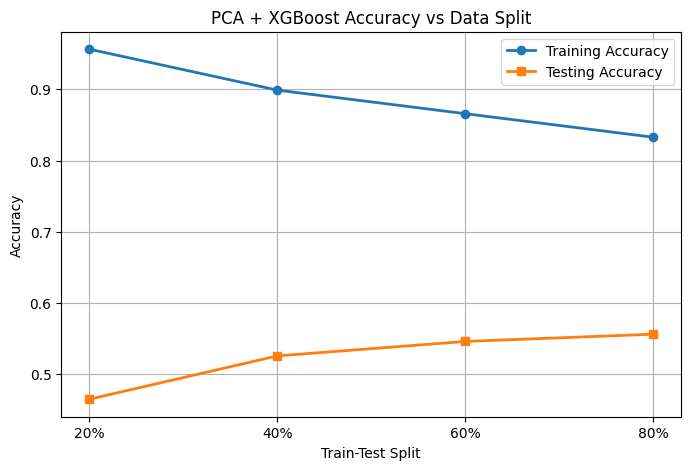

In [ ]:
#accuracy plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_acc_list,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    test_acc_list,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Train-Test Split")

plt.ylabel("Accuracy")

plt.title("PCA + XGBoost Accuracy vs Data Split")

plt.legend()

plt.grid(True)

plt.show()

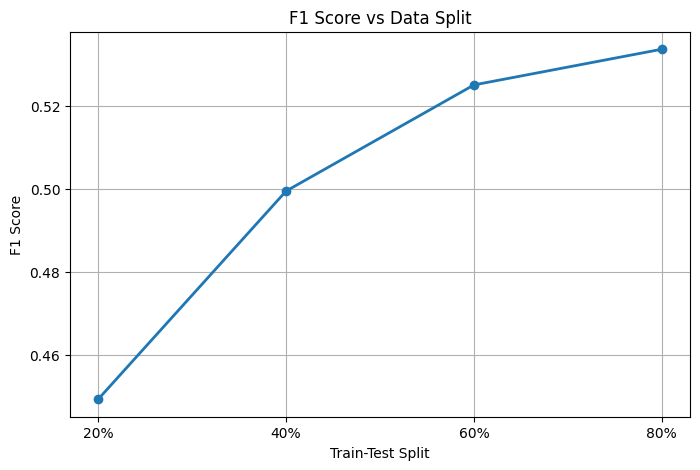

In [ ]:
#f1 plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    f1_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")

plt.ylabel("F1 Score")

plt.title("F1 Score vs Data Split")

plt.grid(True)

plt.show()

In [ ]:
#results table
results_df = pd.DataFrame({
    'Train-Test Split': labels,
    'Training Accuracy': train_acc_list,
    'Testing Accuracy': test_acc_list,
    'F1 Score': f1_list
})

print(results_df)

  Train-Test Split  Training Accuracy  Testing Accuracy  F1 Score
0              20%           0.956446          0.464467  0.449221
1              40%           0.898955          0.525381  0.499485
2              60%           0.865854          0.545685  0.525116
3              80%           0.832753          0.555838  0.533735


In [ ]:
#sample predictions
def display_samples(folder, title, num_samples=9):

    valid_ext = ('.jpg', '.jpeg', '.png')

    imgs = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    imgs = imgs[:num_samples]

    plt.figure(figsize=(12,8))

    for i, filename in enumerate(imgs):

        img_path = os.path.join(folder, filename)

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        img_flat = img.flatten()/255.0

        pred = xgb.predict(
            pca.transform([img_flat])
        )[0]

        plt.subplot(3,3,i+1)

        plt.imshow(
            img,
            cmap='gray'
        )

        plt.title(dec[pred])

        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

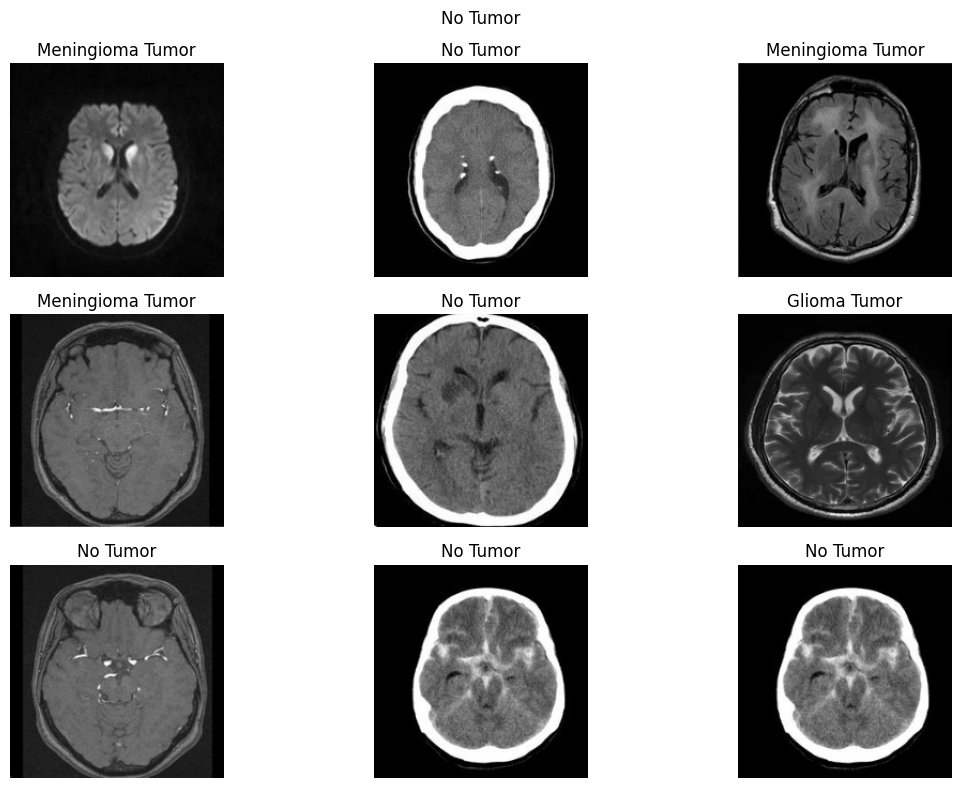

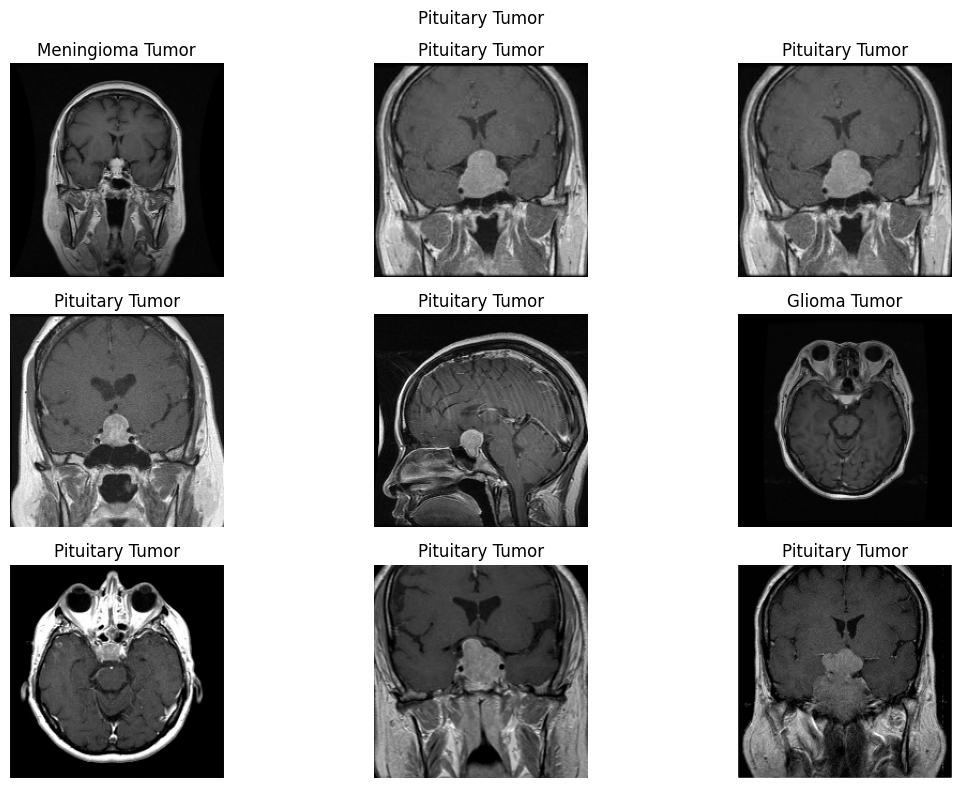

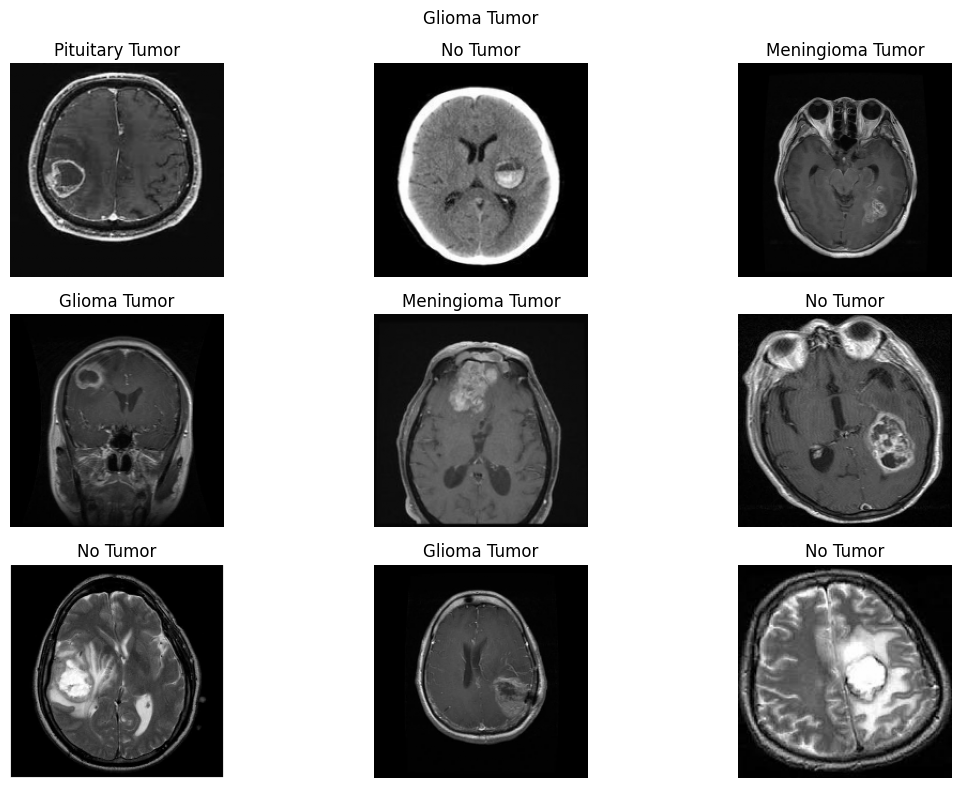

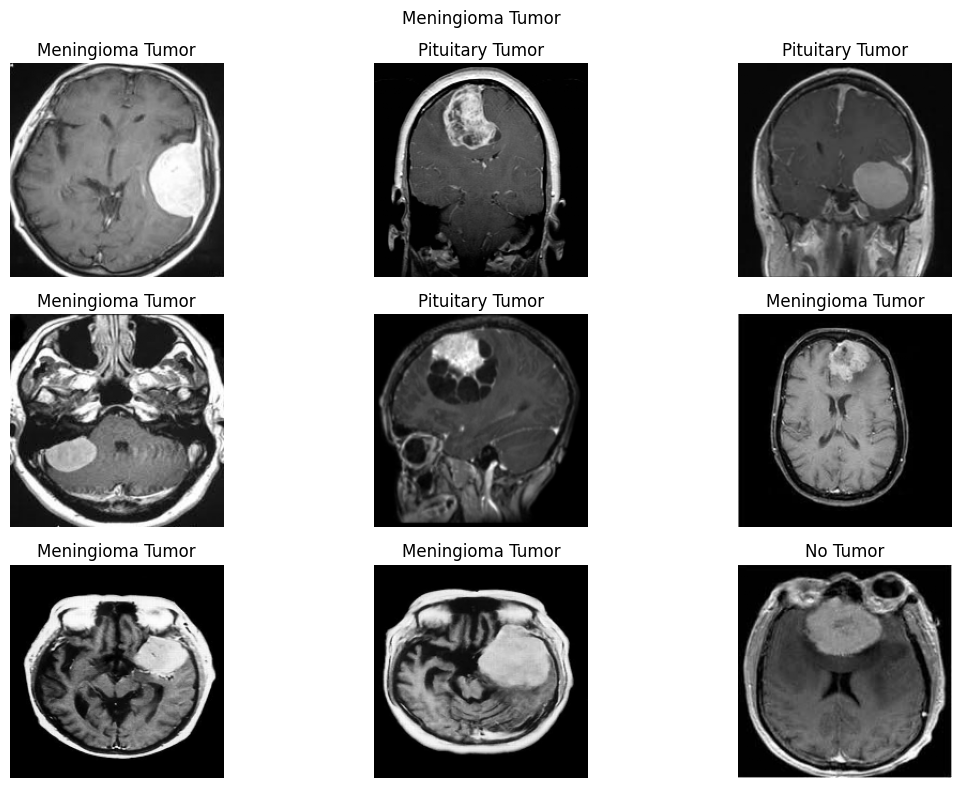

In [ ]:
#display predictions
test_path = os.path.join(path, "Testing")

for tumor_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        tumor_folder
    )

    if os.path.isdir(folder_path):

        display_samples(
            folder_path,
            tumor_folder.replace("_"," ").title()
        )

In [ ]:
#dataset_distribution
tumor_counts = {
    dec[label]: int(np.sum(Y_train == label))
    for label in classes.values()
}

df = pd.DataFrame({
    'Tumor Type': list(tumor_counts.keys()),
    'Count': list(tumor_counts.values())
})

print(df)

         Tumor Type  Count
0          No Tumor    395
1   Pituitary Tumor    827
2      Glioma Tumor    826
3  Meningioma Tumor    822


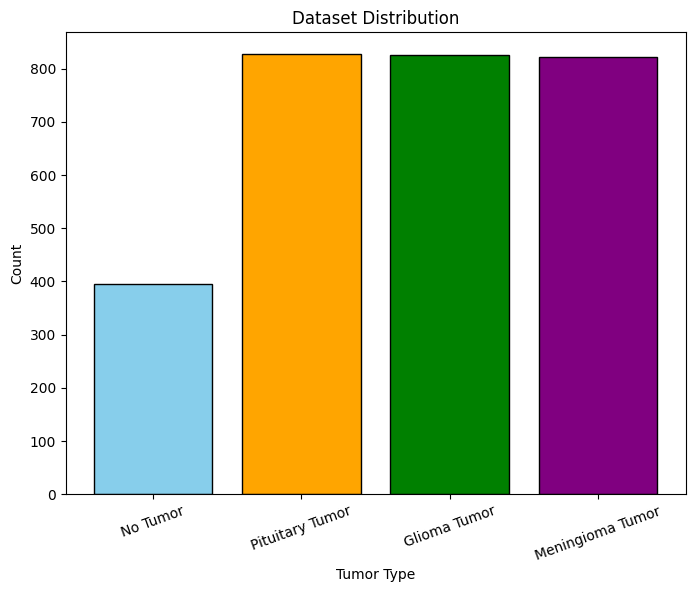

In [ ]:
#distribution plot
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8,6))

for label, color in zip(classes.values(), colors):

    plt.bar(
        dec[label],
        int(np.sum(Y_train == label)),
        color=color,
        edgecolor='black'
    )

plt.xlabel("Tumor Type")

plt.ylabel("Count")

plt.title("Dataset Distribution")

plt.xticks(rotation=20)

plt.show()

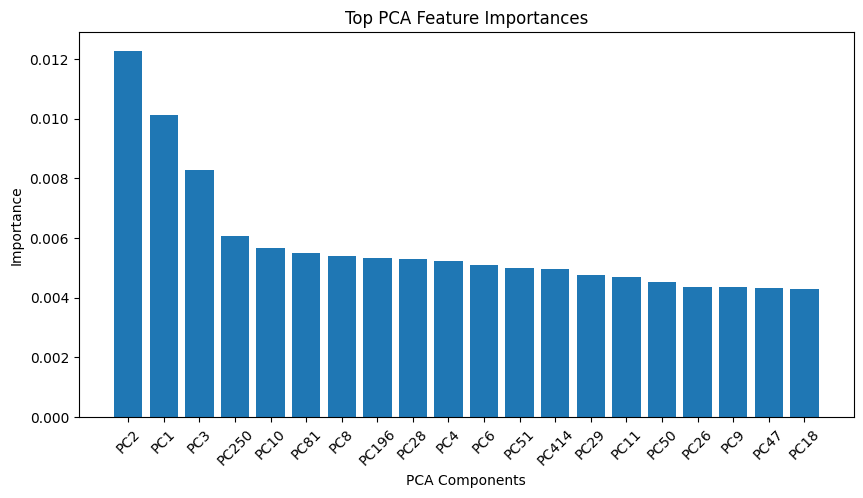

In [ ]:
#feature importance
importances = xgb.feature_importances_

top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10,5))

plt.bar(
    range(20),
    importances[top_idx]
)

plt.xticks(
    range(20),
    [f"PC{idx+1}" for idx in top_idx],
    rotation=45
)

plt.xlabel("PCA Components")

plt.ylabel("Importance")

plt.title("Top PCA Feature Importances")

plt.show()